In [1]:
import sys
sys.path.append('..')

In [2]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

In [3]:
from analysis.utils.visualization_fn import plot_age_histogram
from analysis.utils.visualization_fn import plot_age_by_group
from analysis.utils.visualization_fn import plot_age_vs_sex
from analysis.utils.visualization_fn import plot_intensity_histogram
from analysis.utils.visualization_fn import show_mid_slice

In [4]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:
# Paths
OPENBHB_BASE = "../data/raw/openbhb/val_quasiraw"
TSV_PATH = "../data/raw/openbhb/participants.tsv"

In [6]:
meta_df = pd.read_csv(TSV_PATH, sep='\t')
print(f"Total subjects: {len(meta_df)}")
meta_df.head()

Total subjects: 628


,participant_id,study,sex,age,site,diagnosis,tiv,csfv,gmv,wmv,magnetic_field_strength,acquisition_setting
0,128044719091,3,female,21.000000,26.0,control,1445.385803,284.886930,667.248644,492.831205,3.0,1.0
1,262333993605,2,female,16.333333,58.0,control,1496.715051,203.081235,741.359976,551.673267,3.0,1.0
2,278184896453,3,male,25.000000,26.0,control,1441.856265,225.730021,673.424777,542.390143,3.0,1.0
3,407639789848,2,male,15.583333,58.0,control,1436.948820,240.729871,707.832910,487.779169,3.0,1.0
4,418353205823,7,male,72.500000,38.0,control,1330.169138,374.878038,512.001178,441.799739,3.0,1.0


In [7]:
meta_df.columns

Index(['participant_id', 'study', 'sex', 'age', 'site', 'diagnosis', 'tiv',
       'csfv', 'gmv', 'wmv', 'magnetic_field_strength', 'acquisition_setting'],
      dtype='object')

In [8]:
meta_df.head()

,participant_id,study,sex,age,site,diagnosis,tiv,csfv,gmv,wmv,magnetic_field_strength,acquisition_setting
0,128044719091,3,female,21.000000,26.0,control,1445.385803,284.886930,667.248644,492.831205,3.0,1.0
1,262333993605,2,female,16.333333,58.0,control,1496.715051,203.081235,741.359976,551.673267,3.0,1.0
2,278184896453,3,male,25.000000,26.0,control,1441.856265,225.730021,673.424777,542.390143,3.0,1.0
3,407639789848,2,male,15.583333,58.0,control,1436.948820,240.729871,707.832910,487.779169,3.0,1.0
4,418353205823,7,male,72.500000,38.0,control,1330.169138,374.878038,512.001178,441.799739,3.0,1.0


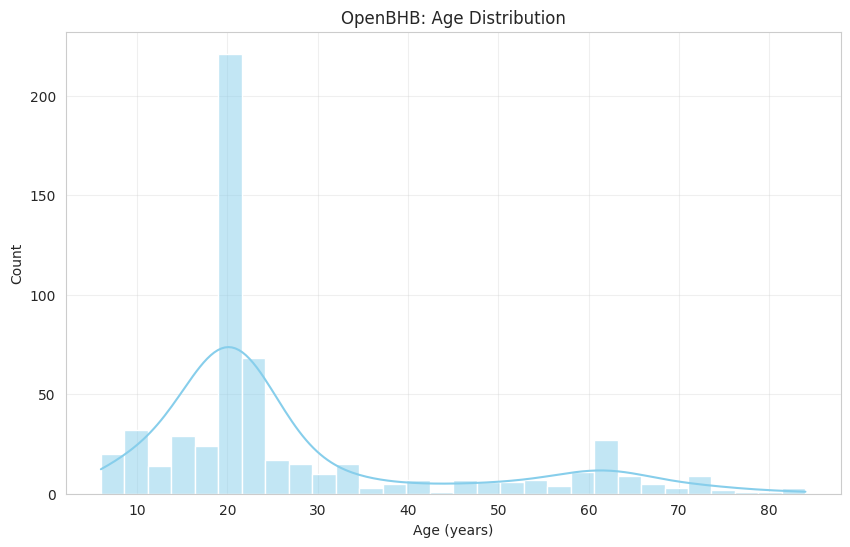

In [9]:
plot_age_histogram(
    meta_df['age'], 
    title="OpenBHB: Age Distribution", 
    save_path="../analysis/figures/openbhb_age_all.png"
)

In [10]:
site_counts = meta_df['site'].value_counts()
print("Number of sites:", len(site_counts))
print(site_counts)

Number of sites: 12
site
54.0    256
41.0    179
62.0     69
67.0     23
69.0     20
68.0     20
36.0     18
39.0      9
52.0      4
58.0      3
26.0      2
38.0      1
Name: count, dtype: int64


/home/nilsagor/Documents/paper_project/brain_age_project/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 61.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


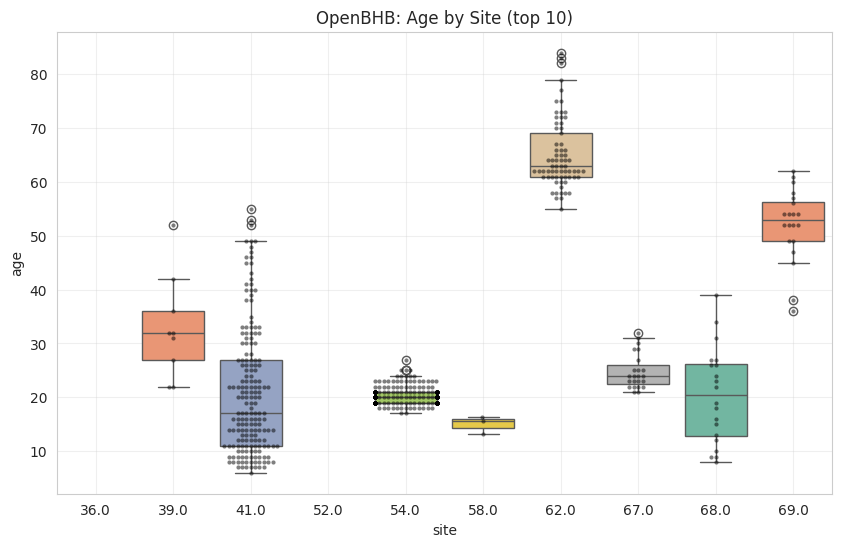

In [11]:
# For boxplot, limit to top N sites for readability
top_sites = site_counts.head(10).index
df_top = meta_df[meta_df['site'].isin(top_sites)]
plot_age_by_group(
    df_top, 
    age_col='age', 
    group_col='site', 
    title="OpenBHB: Age by Site (top 10)", 
    save_path="../analysis/figures/openbhb_age_by_site.png"
)

In [12]:
meta_df['sex'].head()

0    female
1    female
2      male
3      male
4      male
Name: sex, dtype: object

In [13]:
sex_counts = meta_df['sex'].value_counts()
print(sex_counts)
plot_age_vs_sex(
    meta_df['age'], 
    meta_df['sex'], 
    title="OpenBHB: Age by Sex", 
    save_path="../analysis/figures/openbhb_age_by_sex.png"
)

sex
male      296
female    293
Name: count, dtype: int64


TypeError: '<' not supported between instances of 'str' and 'float'